In [1]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import os
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import glob
import numpy as np

In [2]:
Synthetic = pd.read_csv('/Users/sankalpyadava/Desktop/Biocomplexity Institute/synthetic.csv')
Advan = pd.read_csv('/Users/sankalpyadava/Desktop/Biocomplexity Institute/Advan.csv')

In [3]:
synthetic_agg = (Synthetic.groupby(['lid', 'latitude', 'longitude', 'admin2'])
                 .size()
                 .reset_index(name='visit_count_synthetic'))

advan_agg = (Advan.groupby(['placekey', 'latitude', 'longitude', 'county'])
             .size()
             .reset_index(name='visit_count_advan'))


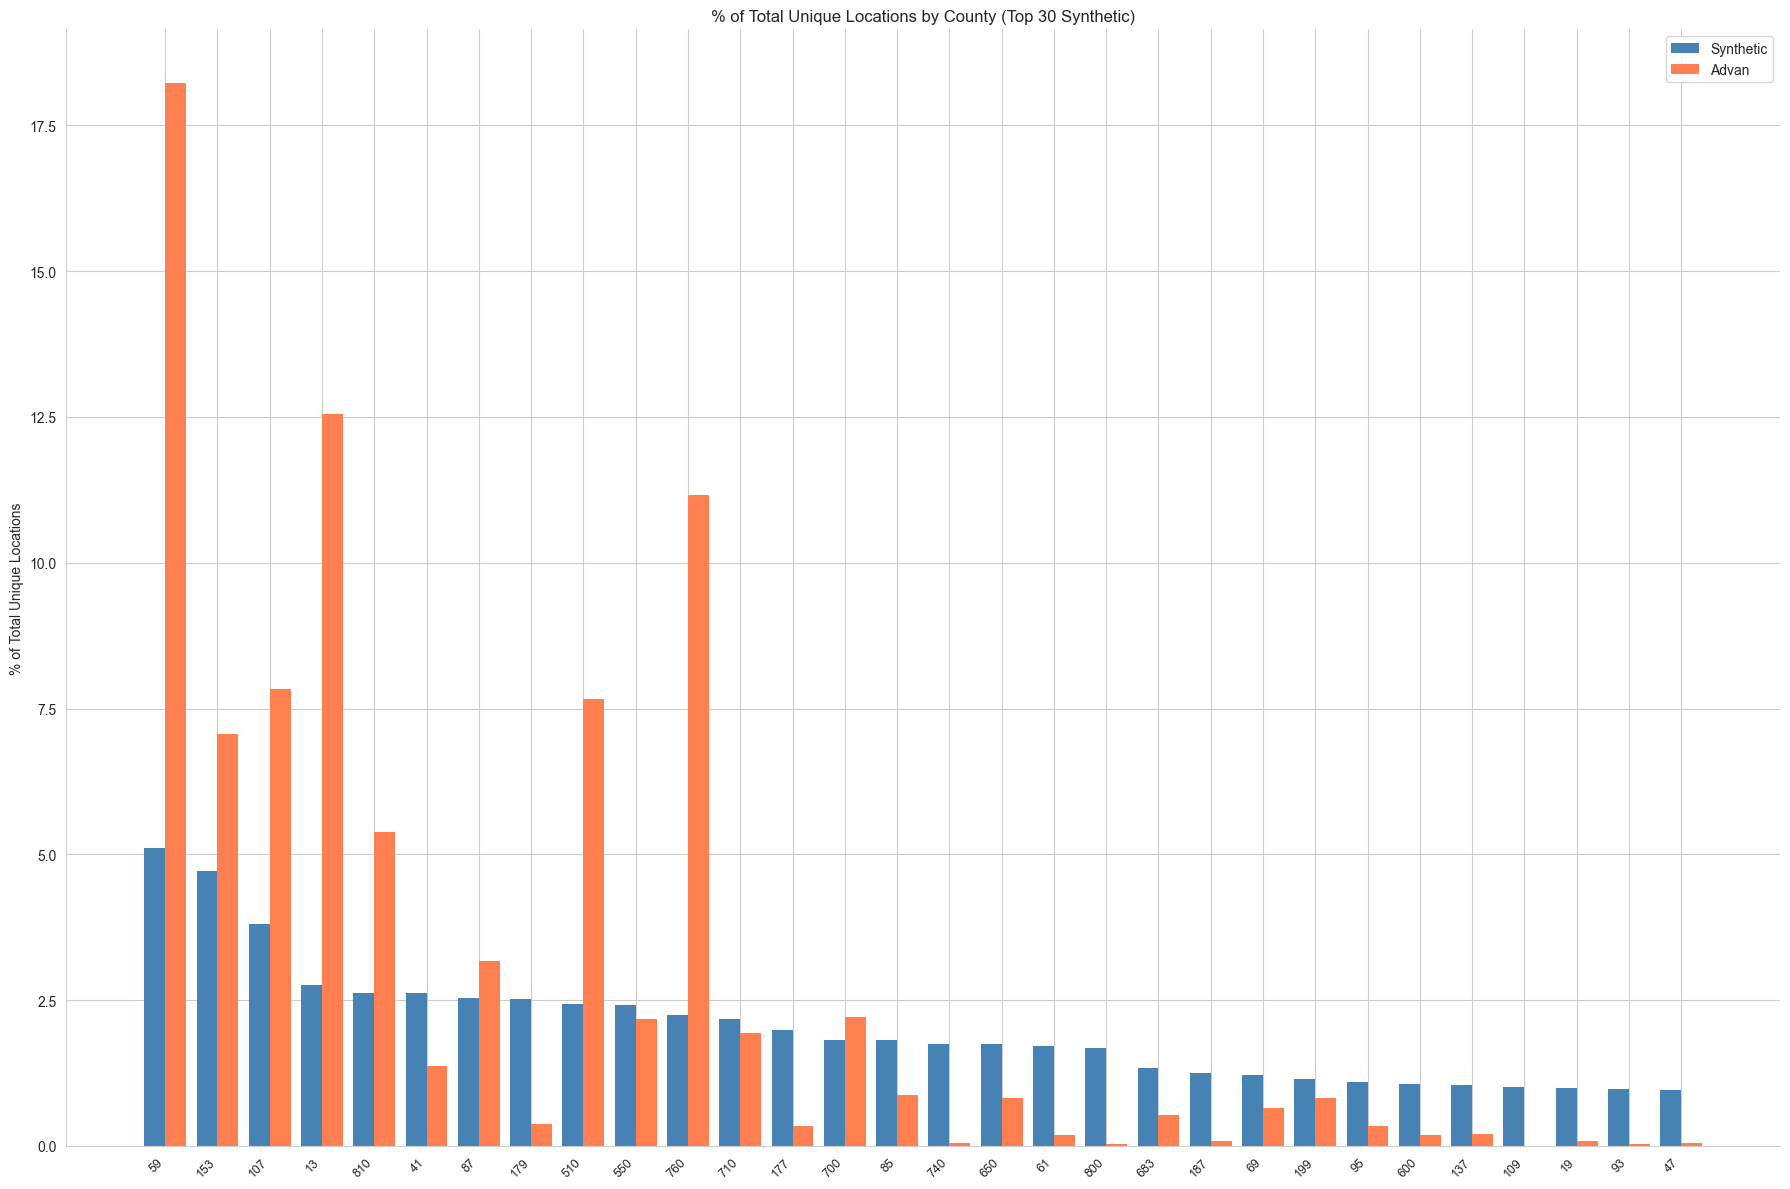

In [13]:
# Unique locations per county
synthetic_unique = synthetic_agg.groupby('admin2').size().reset_index(name='unique_locs_synthetic')
advan_unique = advan_agg.groupby('county').size().reset_index(name='unique_locs_advan')

# Normalize to percentage of total unique locations
synthetic_unique['pct_synthetic'] = (synthetic_unique['unique_locs_synthetic'] / synthetic_unique['unique_locs_synthetic'].sum()) * 100
advan_unique['pct_advan'] = (advan_unique['unique_locs_advan'] / advan_unique['unique_locs_advan'].sum()) * 100

# Top 30 synthetic, match advan
top30_syn = synthetic_unique.nlargest(30, 'pct_synthetic').sort_values('pct_synthetic', ascending=False)
advan_matched = advan_unique.set_index('county').reindex(top30_syn['admin2'])['pct_advan'].fillna(0).values

# Plot
x = range(len(top30_syn))
width = 0.4

fig, ax = plt.subplots(figsize=(18, 12))
ax.bar([i - width/2 for i in x], top30_syn['pct_synthetic'], width=width,
       color='steelblue', edgecolor='none', label='Synthetic')
ax.bar([i + width/2 for i in x], advan_matched, width=width,
       color='coral', edgecolor='none', label='Advan')

ax.set_xticks(list(x))
ax.set_xticklabels(top30_syn['admin2'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('% of Total Unique Locations')
ax.set_title('% of Total Unique Locations by County (Top 30 Synthetic)')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

In [38]:
g_points = synthetic_agg[['latitude', 'longitude', 'visit_count_synthetic']].values.T
r_points = advan_agg[['latitude', 'longitude', 'visit_count_advan']].values.T

In [29]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
from sklearn.preprocessing import StandardScaler

combined = np.hstack([g_points, r_points]).T
scaler = StandardScaler().fit(combined)
g_scaled = scaler.transform(g_points.T).T
r_scaled = scaler.transform(r_points.T).T

k = 10
knn_r = NearestNeighbors(n_neighbors=k).fit(r_scaled.T)
knn_g = NearestNeighbors(n_neighbors=k).fit(g_scaled.T)

dist_g_in_r, _ = knn_r.kneighbors(g_scaled.T)
dist_r_in_r, _ = knn_r.kneighbors(r_scaled.T)

eps = 1e-10
ce_gr = np.mean(np.log(np.clip(dist_g_in_r[:, k-1], eps, None)))
h_r = np.mean(np.log(np.clip(dist_r_in_r[:, k-1], eps, None)))

pce = ce_gr - h_r
print(f"PCE (KNN): {pce:.4f}")

PCE (KNN): 5.0465


In [35]:
dist_r_in_g, _ = knn_g.kneighbors(r_scaled.T)

eps = 1e-10
ce_rg = np.mean(np.log(np.clip(dist_r_in_g[:, k-1], eps, None)))
h_r

rce = ce_rg - h_r
print(f"RCE (KNN): {rce:.4f}")

RCE (KNN): 0.6601


In [34]:
dist_g_in_g, _ = knn_g.kneighbors(g_scaled.T)

eps = 1e-10
h_g = np.mean(np.log(np.clip(dist_g_in_g[:, k-1], eps, None)))
h_r

re = h_g - h_r
print(f"H(G) - Synthetic Entropy: {h_g:.4f}")
print(f"H(R) - Advan Entropy:     {h_r:.4f}")
print(f"RE (KNN): {re:.4f}")

H(G) - Synthetic Entropy: -8.3380
H(R) - Advan Entropy:     -7.0769
RE (KNN): -1.2611
